# Solution 3

## Tamir Cohen

### Q1

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import time

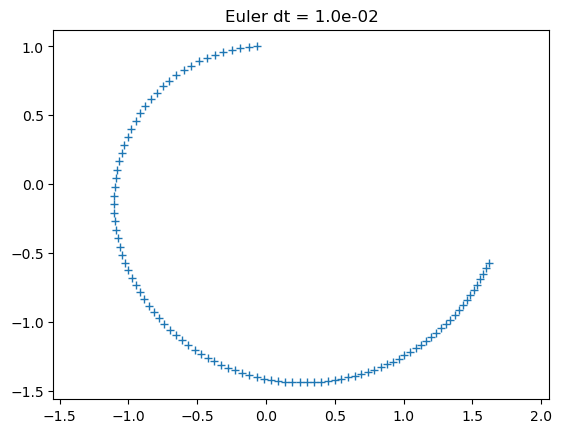

In [4]:
def FO_Euler_func (x,y,vx,vy,dt):
    global GM
    dvx =  -GM/((x**2 + y**2)**(3/2)) * x * dt
    dvy =  -GM/((x**2 + y**2)**(3/2)) * y * dt

    dx =  vx * dt
    dy =  vy * dt
    return dx, dy, dvx, dvy
    


def main():
    global GM
    GM = 4*np.pi**2;

    a = 1
    e = 0
    
    x0 = 0; y0 = a*(1-e);
    vx0 =-np.sqrt( GM/a * (1+e)/(1-e) ) ; vy0 = 0

    x=x0; y=y0; vx=vx0; vy=vy0;
    
    T = 1 # single orbit
    dt = 1e-2
    t = 0
    X = np.array([]); Y=X; VX=Y; VY=VX;
    count = 0
    
    while t<=T:
        # count +=1
        # print (count)
        dx, dy, dvx, dvy = FO_Euler_func (x,y,vx,vy,dt)
        x+=dx; y+=dy; vx+=dvx; vy+=dvy;
        
        X = np.append(X,x); Y = np.append(Y,y); 
        VX = np.append(VX,vx); VY = np.append(VY,vy); 
        
        t+=dt
        # plt.plot(x,y,'o')        # print(y)
    # plt.show()        
    # print(X)
    # print(Y)
    
    plt.plot(X,Y,'+')
    plt.title (f'Euler dt = {dt:.1e}' )
    plt.axis('equal')
    plt.show()


if True:
    main()
    
    
        
    
    
    
    
    








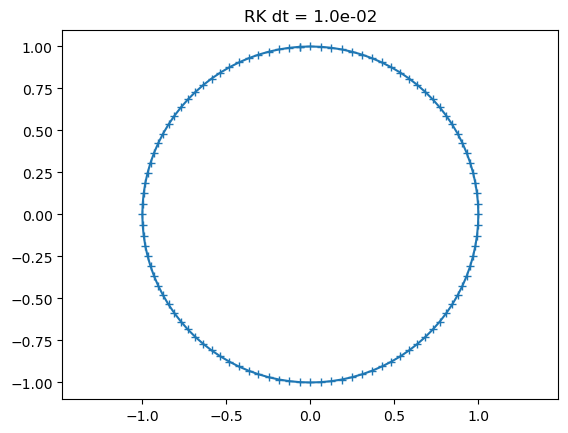

In [5]:
def Forth_Order_RK (x,y,vx,vy,dt):
    global GM

    ## K1 
    k1vx = -GM/((x**2 + y**2)**(3/2)) * x * dt
    k1vy = -GM/((x**2 + y**2)**(3/2)) * y * dt
    k1x =  vx * dt
    k1y =  vy * dt
    
    ## K2
    k2vx = -GM/(( (x+k1x/2)**2 + (y+k1y/2)**2) **(3/2)) * (x+k1x/2) * dt
    k2vy = -GM/(( (x+k1x/2)**2 + (y+k1y/2)**2) **(3/2)) * (y+k1y/2) * dt
    k2x =  (vx+k1vx/2) * dt
    k2y =  (vy+k1vy/2) * dt
    ## K3
    k3vx = -GM/(( (x+k2x/2)**2 + (y+k2y/2)**2) **(3/2)) * (x+k2x/2) * dt
    k3vy = -GM/(( (x+k2x/2)**2 + (y+k2y/2)**2) **(3/2)) * (y+k2y/2) * dt
    k3x =  (vx+k2vx/2) * dt
    k3y =  (vy+k2vy/2) * dt

    ## K4
    k4vx = -GM/(( (x+k3x)**2 + (y+k3y)**2) **(3/2)) * (x+k3x) * dt
    k4vy = -GM/(( (x+k3x)**2 + (y+k3y)**2) **(3/2)) * (y+k3y) * dt
    k4x =  (vx+k3vx) * dt
    k4y =  (vy+k3vy) * dt

    ## calculate the deviations
    dvx = 1/6 * (k1vx + 2*k2vx + 2*k3vx + k4vx)
    dvy = 1/6 * (k1vy + 2*k2vy + 2*k3vy + k4vy)
    dx  = 1/6 * (k1x  + 2*k2x  + 2*k3x  + k4x)
    dy  = 1/6 * (k1y  + 2*k2y  + 2*k3y  + k4y)

    return dx, dy, dvx, dvy
    


def main():
    global GM
    GM = 4*np.pi**2;

    a = 1
    e = 0
    
    x0 = 0; y0 = a*(1-e);
    vx0 =-np.sqrt( GM/a * (1+e)/(1-e) ) ; vy0 = 0

    x=x0; y=y0; vx=vx0; vy=vy0;
    
    T = 1 # single orbit
    dt = 1e-2
    t = np.linspace(0,T,round(1/dt)+1)
#     print (t)
#     t = 0
    X = np.array([]); Y=X; VX=Y; VY=VX;
#     count = 0
    
    for tt in t:
        # count +=1
        # print (count)
        dx, dy, dvx, dvy = Forth_Order_RK (x,y,vx,vy,dt)
        x+=dx; y+=dy; vx+=dvx; vy+=dvy;
        
        X = np.append(X,x); Y = np.append(Y,y); 
        VX = np.append(VX,vx); VY = np.append(VY,vy); 
        
#         t+=dt
#         print (tt)
        # plt.plot(x,y,'o')        # print(y)
    # plt.show()        
    # print(X)
    # print(Y)
        # print(dx)
    plt.plot(X,Y,'-+')
    plt.title (f'RK dt = {dt:.1e}' )
    plt.axis('equal')
    plt.show()
    


if True:
    main()

### Q2

In [131]:
import matplotlib.pyplot as plt
import numpy as np
import time

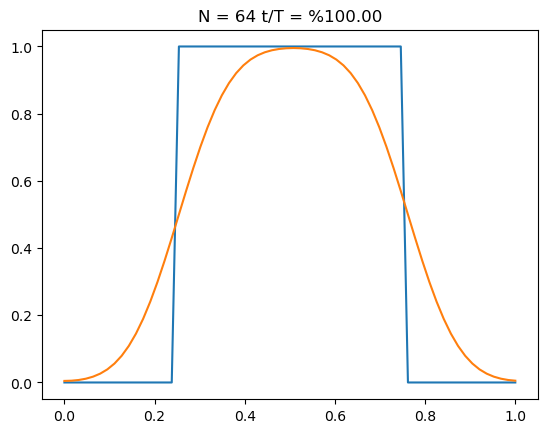

In [132]:
def step_func (Vec_len):
    x = np.linspace(0, 1, Vec_len)  
    y = np.abs(np.where(np.sign(np.cos(2 * np.pi / 1 * x)) > 0, 1, 0)-1) # fliiping sides
    return y

def goust_func(a):
    a_= np.zeros(len(a)+2)
    a_[1:-1] = np.copy(a)
    a_[-1] = a[0]
    a_[0]  = a[-1]
    return a_
    
def upwind(a,C):
    a = goust_func(a)
    ai = a[1:-1]; aii = a[0:-2]
    return ai - C*(ai-aii)

def eps_func(a_end,a0,N):
    dx = 1/N
    return dx * sum((a_end-a0)**2)

def upwind_advection(C=0.5, N=64, u=1,plot_init=True,plot_mid=False,plot_end=True):
    dx = 1/N; T = 1/u; dt = C/u * dx
    step = []
    step.append(step_func(N))
    t_vec = np.linspace(0,T,round(1/dt)+1)
    x_vec = np.linspace(0,1,N)
    for tt in range(len(t_vec)):
        
        step_ = upwind(step[-1],C)
        step.append(step_)
        
        if tt%50 == 0 and plot_mid == True:   
            plt.plot(x_vec,step[-1]); plt. title (f't/T = %{t_vec[tt]/T*100:.2f}'); plt.show() 
    if plot_end == True:
        if plot_init == True:
            plt.plot(x_vec,step[0]); plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}')
        
        plt.plot(x_vec,step[-1]); plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}'); plt.show() 
        plt.show()

    return step


    print("The time stpes dt the sysem is for CLF is between 0 to 1, so the maximal dt is then dx/u where dx=1/N is the grid step")
if upwind_advection:
    upwind_advection()
        

    

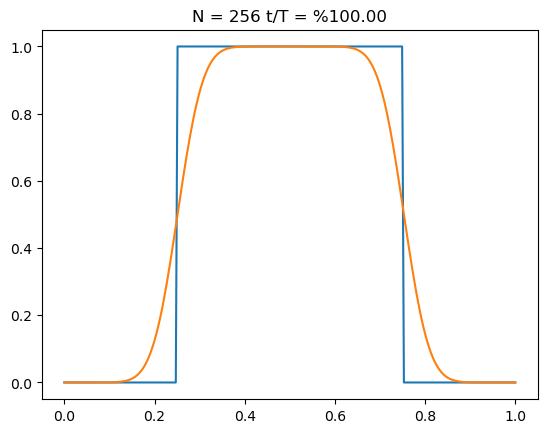

eps = 2.07226e-02


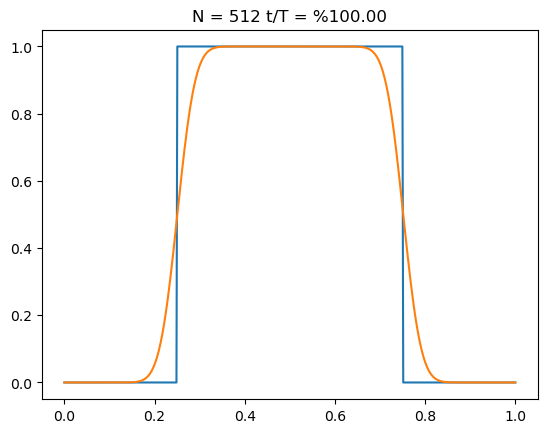

eps = 1.46295e-02


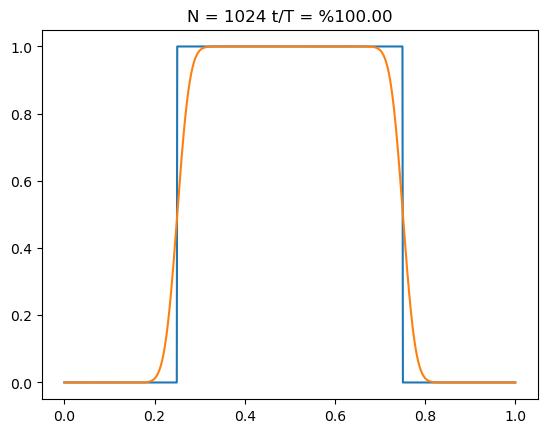

eps = 1.03363e-02


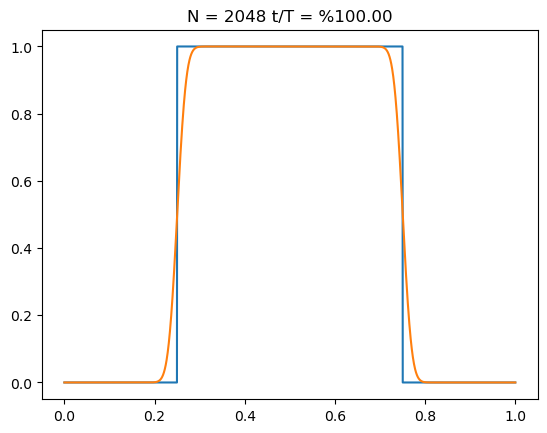

eps = 7.30592e-03


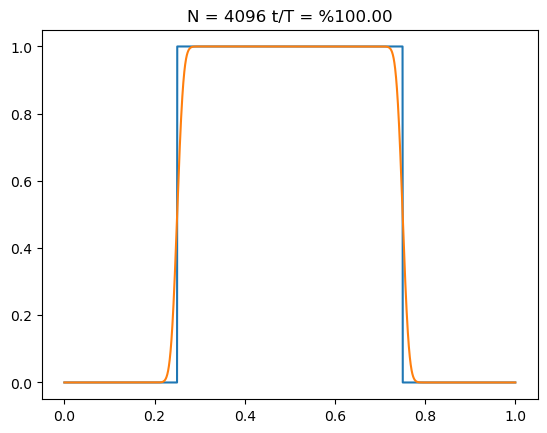

eps = 5.16502e-03


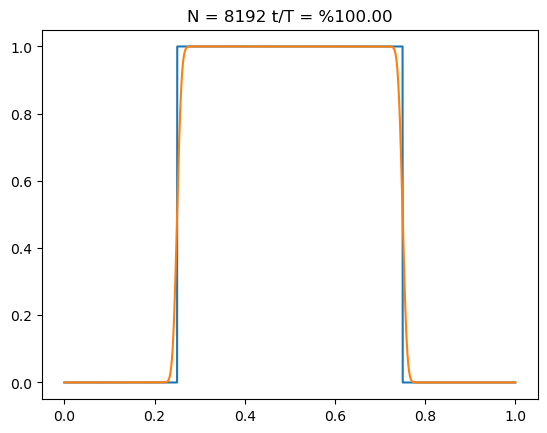

eps = 3.65185e-03


In [133]:
power_vec = np.arange(8,14,1);
N_vec = 2**power_vec
eps_up = []
for N in N_vec:
    a = upwind_advection(C=0.5 ,N=N , u=1, plot_init=True, plot_mid=False, plot_end=True)
    eps_up.append(eps_func(a[-1],a[0],N))
    print(f'eps = {eps_up[-1]:.5e}')
    



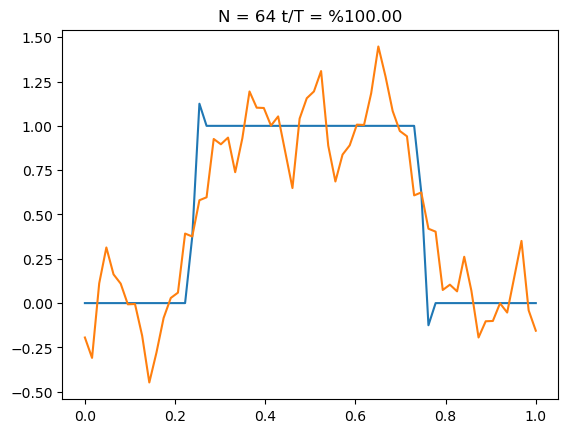

In [134]:
def step_func (Vec_len):
    x = np.linspace(0, 1, Vec_len)  
    y = np.abs(np.where(np.sign(np.cos(2 * np.pi / 1 * x)) > 0, 1, 0)-1) # fliiping sides
    return y

def goust_func(a):

    
    a_ = np.zeros(len(a)+2)
    a_[1:-1] = np.copy(a)
    a_[-1] = a[0]; #  a_N-1 = a_0
    # a_[-1] = a[1] # a_N = a1
    a_[0] = a[-1]  # a_-1 = a_N-2
    return a_
    
def lax_func (a,C):
    a_ = goust_func(a)
    aip1 = a_[2:]; aim1 = a_[:-2]
    return a + C/2*(aip1-aim1)+ (C**2)/2 * (aip1+aim1-2*a)
    
    
def upwind(a,a_prev_n,C):
    a_ = goust_func(a)    
    aip1 = a_[2:]; aim1 = a_[:-2]
    return a_prev_n - C*(aip1-aim1)

def eps_func(a_end,a0,N):
    dx = 1/N
    return dx * sum((a_end-a0)**2)




def leapfrog_func(C=0.5, N=2**6, u=1,plot_init=True,plot_mid=False,plot_end=True):
    dx = 1/N; T = 1/u; dt = C/u * dx
    step = []
    stepm2 = np.zeros(N)
    # print(stepm2[0])
    # step.append(stepm2)
    step.append(step_func(N))
    step.append(lax_func (step[-1],C))
    # step.append(step_func(N))
    # print(step[-1])
    t_vec = np.linspace(0,T,round(1/dt)+1)
    x_vec = np.linspace(0,1,N)
    
    for tt in range(len(t_vec)):
        
        step_new = upwind(step[-1],step[-2],C)
        # print(len(step_tx))
        step.append(step_new)
        if tt%50 == 0 and plot_mid == True:   
            plt.plot(x_vec,step[-1]); plt. title (f't/T = %{t_vec[tt]/T*100:.2f}'); plt.show() 
    if plot_end == True:
        if plot_init == True:
            plt.plot(x_vec,step[1]); plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}')
        
        plt.plot(x_vec,step[-1]); plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}'); plt.show() 
        plt.show()

    return step
        
if leapfrog_func:
    leapfrog_func()


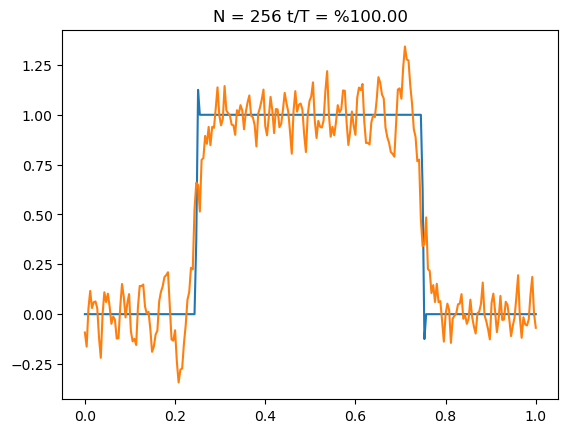

eps = 2.06976e-02


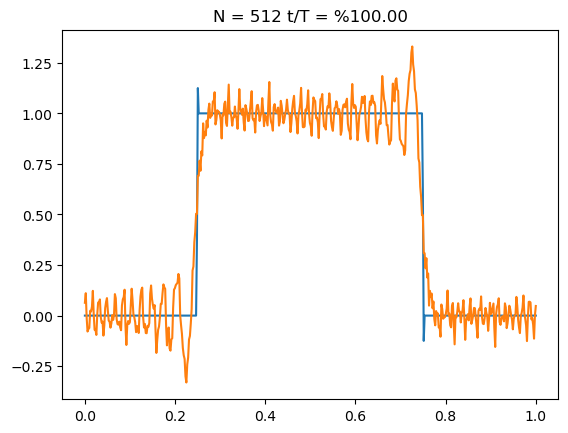

eps = 1.15266e-02


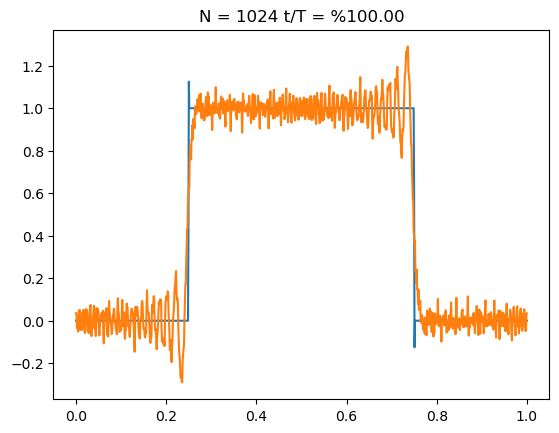

eps = 7.56952e-03


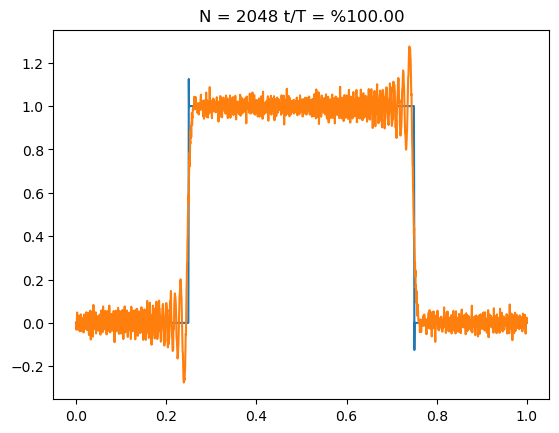

eps = 4.62569e-03


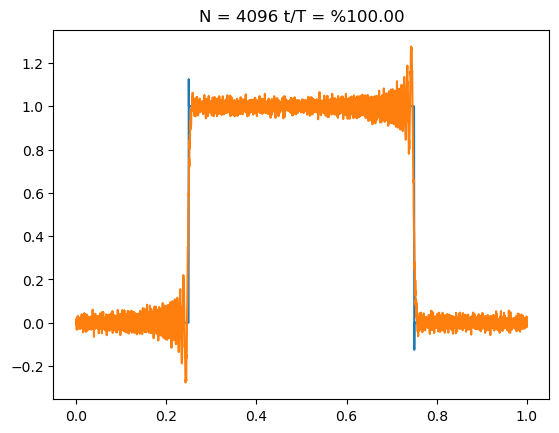

eps = 2.92868e-03


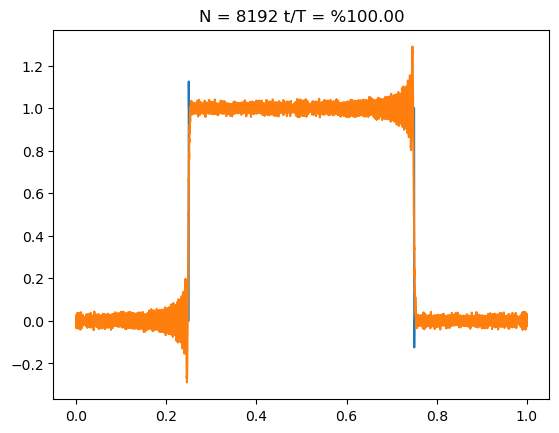

eps = 1.85723e-03


In [135]:
power_vec = np.arange(8,14,1);
N_vec = 2**power_vec
eps_leap = []
for N in N_vec:
    a = leapfrog_func(C=0.5 ,N=N , u=1, plot_init=True, plot_mid=False, plot_end=True)
    eps_leap.append(eps_func(a[-1],a[0],N))
    print(f'eps = {eps_leap[-1]:.5e}')
    

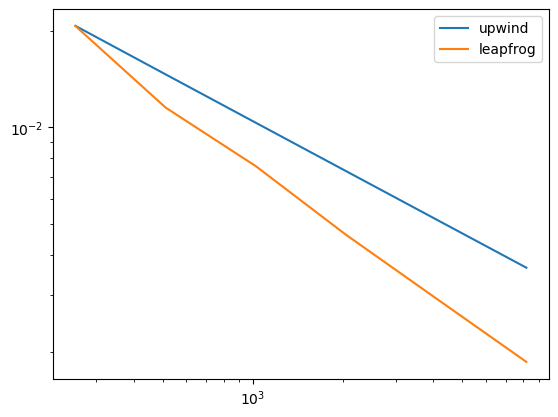

In [136]:
plt.plot(2**power_vec, eps_up)
plt.plot(2**power_vec, eps_leap)
plt.yscale('log')
plt.xscale('log')
plt.legend(["upwind","leapfrog"])
plt.show()


### Q3

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import time

####  uniform reconstruction

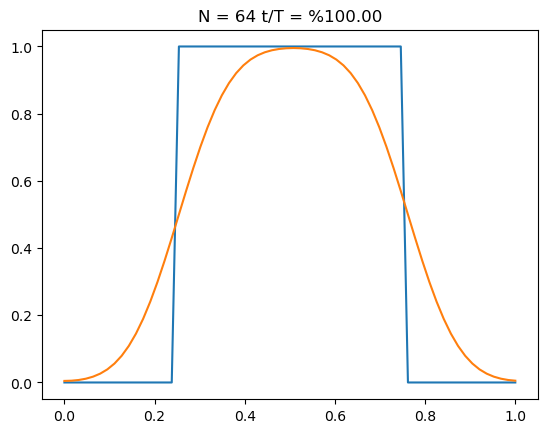

In [137]:
def step_func (Vec_len):
    x = np.linspace(0, 1, Vec_len)  
    y = np.abs(np.where(np.sign(np.cos(2 * np.pi / 1 * x)) > 0, 1, 0)-1) # fliiping sides
    return y

def goust_func(a):
    a_= np.zeros(len(a)+2)
    a_[1:-1] = np.copy(a)
    a_[-1] = a[0]
    a_[0]  = a[-1]
    return a_
    
    
def upwind(a,C,u):
    a_ = goust_func(a)
    
    if u>0:
        ai = a_[1:-1]; aii = a_[0:-2]
        
    else:
        ai = a_[2:]; aii = a_[1:-1]
        
    return ai - C*(ai-aii)




def eps_func(a_end,a0,N):
    dx = 1/N
    return dx * sum((a_end-a0)**2)

def uni_advection(C=0.5, N=2**6, u=1,plot_init=True,plot_mid=False,plot_end=True):
    dx = 1/N; T = 1/np.abs(u); dt = C/np.abs(u) * dx
    step = []
    step.append(step_func(N))
    t_vec = np.linspace(0,T,round(1/dt)+1)
    x_vec = np.linspace(0,1,N)
    for tt in range(len(t_vec)):
        
        step_t = upwind(step[-1],C,u)
#         step_tx = upwind_x(step_t,dx)
        step.append(step_t)
        
        if tt%50 == 0 and plot_mid == True:   
            plt.plot(x_vec,step[-1]); plt. title (f't/T = %{t_vec[tt]/T*100:.2f}'); plt.show() 
    if plot_end == True:
        if plot_init == True:
            plt.plot(x_vec,step[0]); plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}')
        
        plt.plot(x_vec,step[-1]); plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}'); plt.show() 
        plt.show()

    return step


    print("The time stpes dt the sysem is for CLF is between 0 to 1, so the maximal dt is then dx/u where dx=1/N is the grid step")
if uni_advection:
    uni_advection()
        

    

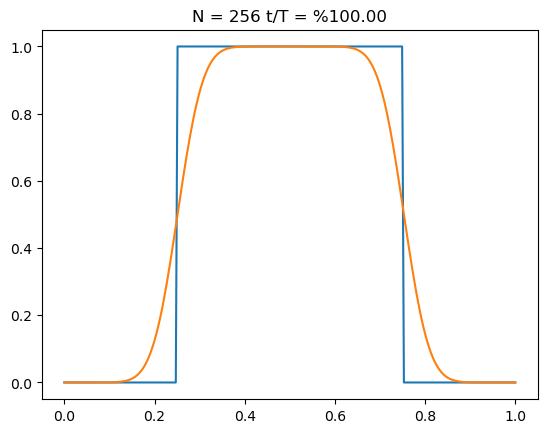

eps = 2.07226e-02


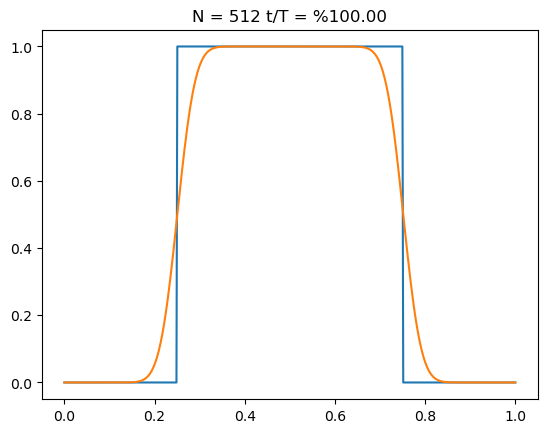

eps = 1.46295e-02


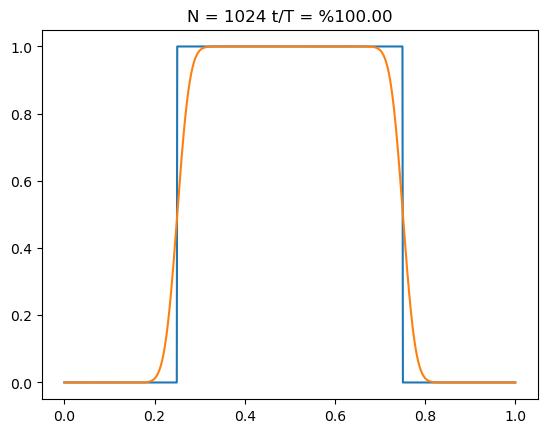

eps = 1.03363e-02


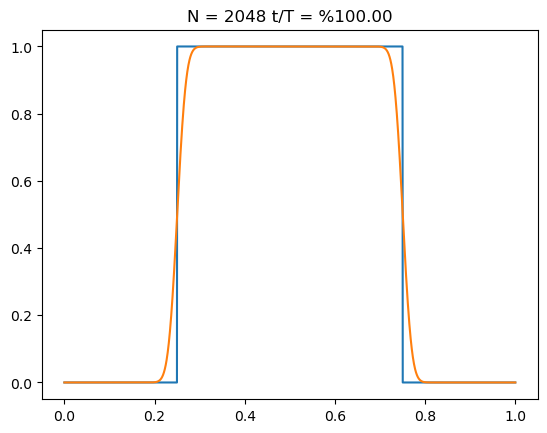

eps = 7.30592e-03


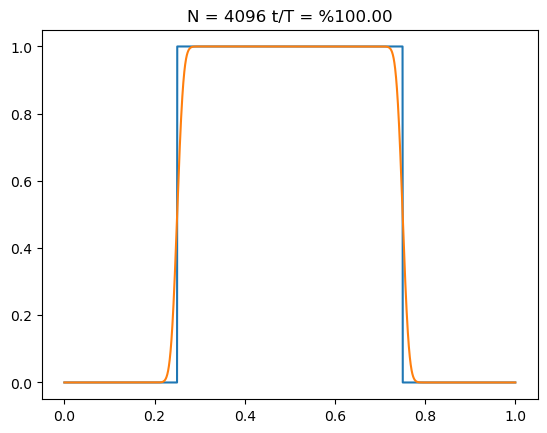

eps = 5.16502e-03


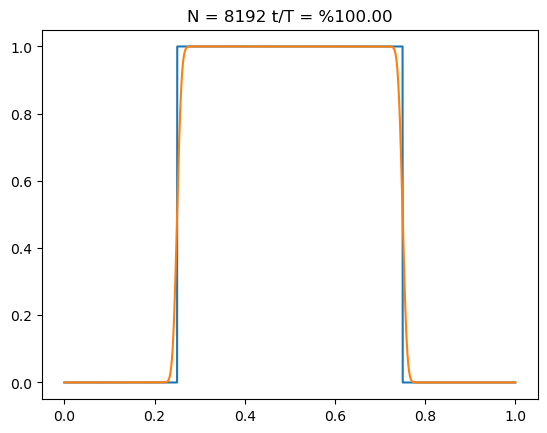

eps = 3.65185e-03


In [138]:
power_vec = np.arange(8,14,1);
N_vec = 2**power_vec
eps_uni = []
for N in N_vec:
    a = Uni_advection(C=0.5, N=N, u=1,plot_init=True,plot_mid=False,plot_end=True)
    eps_uni.append(eps_func(a[-1],a[0],N))
    print(f'eps = {eps_uni[-1]:.5e}')
    

#### Linear piecewise reconstruction

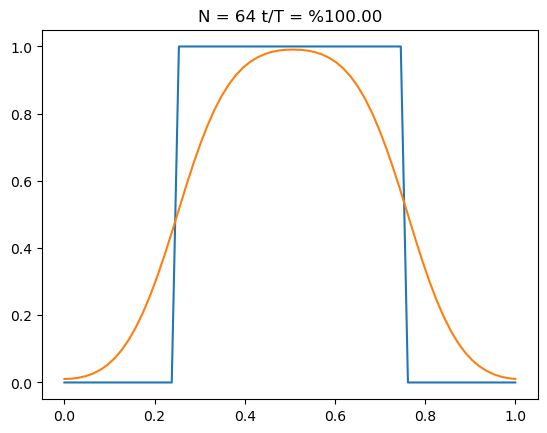

In [148]:
def step_func (Vec_len):
    x = np.linspace(0, 1, Vec_len)  
    y = np.abs(np.where(np.sign(np.cos(2 * np.pi / 1 * x)) > 0, 1, 0)-1) # fliiping sides
    return y

def goust_func(a):
    a_ = np.zeros(len(a)+4)
    a_[2:-2] = np.copy(a)
    a_[-2] = a[0]; #  a_N-1 = a_0
    a_[-1] = a[1] # a_N = a1
    # a_[-1] = a[2]
    a_[0] = a[-2]  # a_-1 = a_N-2
    a_[1] = a[-1]

    return a_

def lax_func (a,C):
    a_ = goust_func(a)
    aip1 = a_[2:-2]; aim1 = a_[0:-4]
    a_new = a + C/2*(aip1-aim1)+ (C**2)/2 * (aip1+aim1-2*a)
    return a_new


def minnod_func(a_):
    Da = np.zeros(len(a_)-2)
    Da_full = np.zeros(len(a_))
    a = a_[1:-1] - a_[:-2]
    b = a_[2:] - a_[1:-1]
    
    mask_a = (np.abs(a) < np.abs(b)) & (a * b > 0)       
    idx_a = np.where(mask_a)[0]
    mask_b = (np.abs(a) > np.abs(b)) & (a * b > 0)       
    idx_b= np.where(mask_b)[0]
    
    mask_z = (np.abs(a) == np.abs(b)) | (a * b < 0) 
    idx_z= np.where(mask_z)[0]
              
    Da[idx_a] = a[idx_a]
    Da[idx_b] = b[idx_b]
    Da[idx_z] = 0
    
#     Da = a_[2:] - a_[:-2]
    Da_full[1:-1] = Da
    
    
    
    return Da_full
    
    
def upwind_l(a,C,dx,dt,u):
    a_ = goust_func(a)
    N = len(a)
    Da = np.zeros(N+4); a_half_x = np.zeros(N+4); F_1_2 = np.zeros(N+4)      
    a_half_t = np.zeros(N+4) 
    k1 = np.zeros(N+4); k2 = np.zeros(N+4)
    
    
    if u>0:
        Da = minnod_func(a_) /2      
        a_half_x = a_ + Da/2 # upwind from left to right  a
        F_1_2 = u*a_half_x
        k1 = -1/dx * (F_1_2[1:]-F_1_2[:-1])
        a_half_t[1:-1] = a_[1:-1] + dt/2*k1[:-1]

        Da = minnod_func(a_half_t) /2   
        a_half_xt = a_half_t + Da/2 # upwind from left to right  
        F_12_12 = u*(a_half_xt[:-1]) 
        
        k2 = -1/dx * (F_12_12[1:] - F_12_12[:-1])
        a_new = a + dt * k2[1:-1]
        
    else:
        Da = minnod_func(a_) /2      
        a_half_x = a_ - Da/2 # upwind from left to right  a
        F_1_2 = u*a_half_x
        k1 = -1/dx * (F_1_2[1:]-F_1_2[:-1])
        a_half_t[1:-1] = a_[1:-1] + dt/2*k1[:-1]
        
#         a_half_t[-1] = a_half_t[0]
        Da = minnod_func(a_half_t) /2   
        a_half_x = a_half_t - Da/2 # upwind from left to right  a
           
        F_12_12 = u*(a_half_x[1:]) 
        k2 = -1/dx * (F_12_12[1:] - F_12_12[:-1])
        a_new = a + dt * k2[1:-1]
        
        
    return a_new
    

def eps_func(a_end,a0,N):
    dx = 1/N
    return dx * sum((a_end-a0)**2)


def linear_reconstract_func(C=0.5, N=2**6, u=1,plot_init=True,plot_mid=False,plot_end=True):
    dx = 1/N; T = 1/np.abs(u); dt = C/np.abs(u) * dx
    step = []
    step.append(step_func(N))
    step.append(lax_func(step[-1],C))
    
    t_vec = np.linspace(0,T,round(1/dt)+1)
    x_vec = np.linspace(0,1,N)
    
    for tt in range(len(t_vec)):
        step_ = upwind_l(step[-1],C,dx,dt,u)
        step.append(step_)
        if tt%20 == 0 and plot_mid == True:   
            plt.plot(x_vec,step[-1]); plt. title (f't/T = %{t_vec[tt]/T*100:.2f}'); plt.show() 
    if plot_end == True:
        if plot_init == True:
            plt.plot(x_vec,step[0]); plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}')
        
        plt.plot(x_vec,step[-1]); plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}'); plt.show() 
        plt.show()
    return step
        
if linear_reconstract_func:
    linear_reconstract_func()

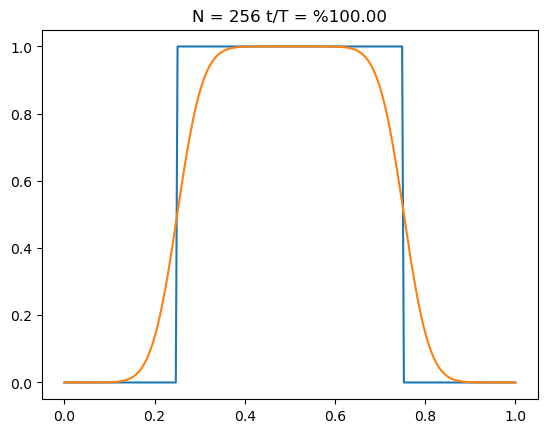

eps = 2.10415e-02


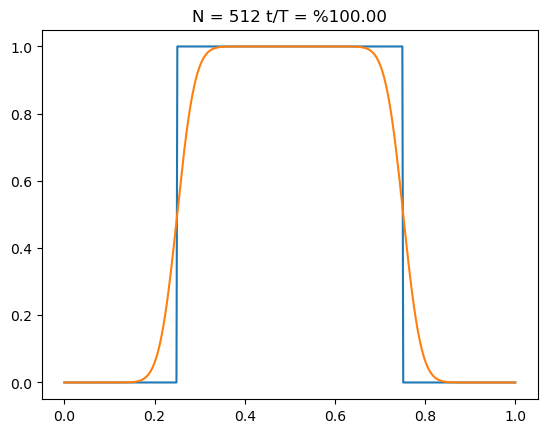

eps = 1.47945e-02


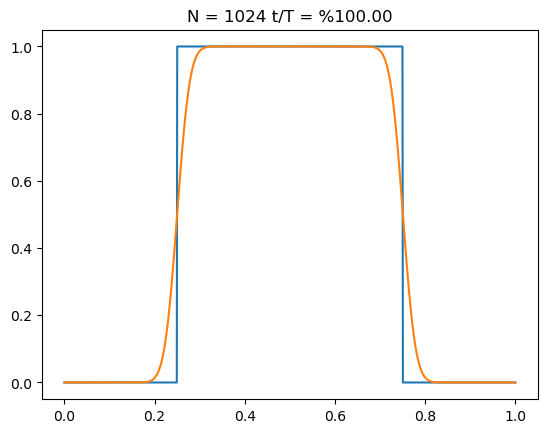

eps = 1.04207e-02


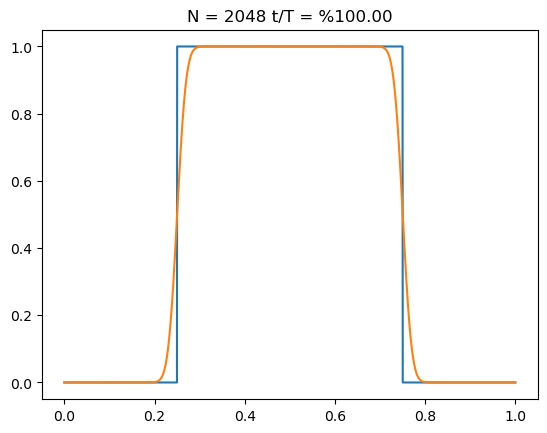

eps = 7.34877e-03


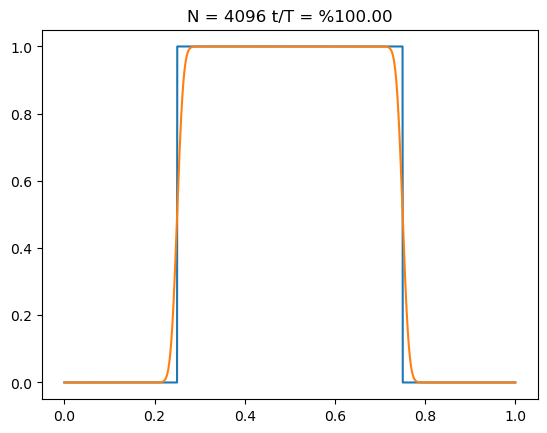

eps = 5.18668e-03


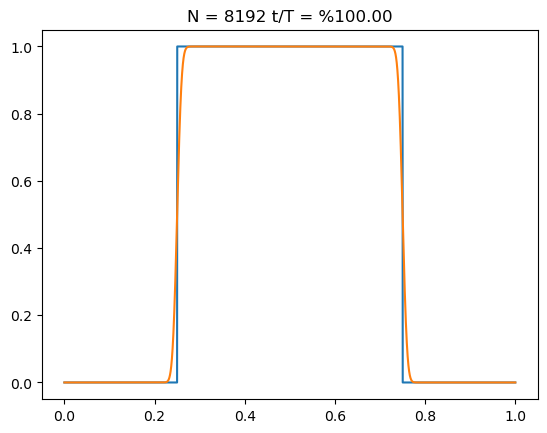

eps = 3.66276e-03


In [149]:
power_vec = np.arange(8,14,1);
N_vec = 2**power_vec
eps_sec = []
for N in N_vec:
    a = linear_reconstract_func(C=0.5, N=N, u=1,plot_init=True,plot_mid=False,plot_end=True)
    eps_sec.append(eps_func(a[-1],a[0],N))
    print(f'eps = {eps_sec[-1]:.5e}')

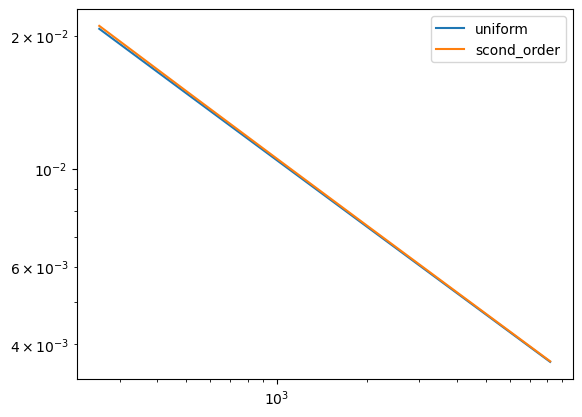

In [150]:
plt.plot(2**power_vec, eps_uni)
plt.plot(2**power_vec, eps_sec)
plt.yscale('log')
plt.xscale('log')
plt.legend(["uniform","scond_order"])
plt.show()
